In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("housing.csv")

In [4]:
df['income_cat'] = pd.cut(df['median_income'], bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf], labels = [1, 2, 3, 4, 5])

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [6]:
# lets remove the income_cat column
for sett in (strat_train_set, strat_test_set):
    sett.drop('income_cat', axis=1, inplace=True)

In [8]:
df = strat_train_set.copy()

<Axes: xlabel='latitude', ylabel='longitude'>

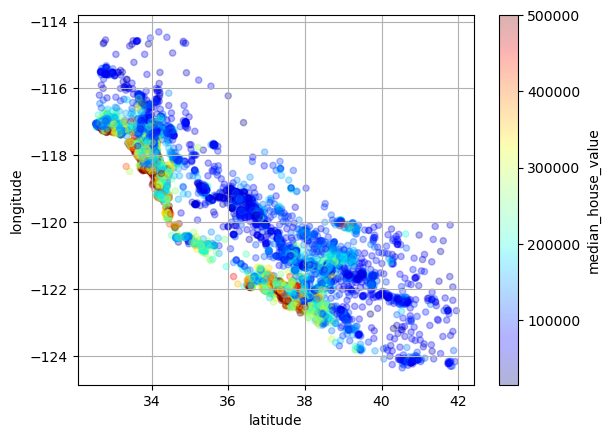

In [11]:
df.plot(kind='scatter', x='latitude', y='longitude', grid=True, alpha=0.3, cmap='jet', c='median_house_value')